# Notebook 07 — LCOE Analysis

**SPE Africa Geothermal Datathon 2026**

## Purpose
Calculate the Levelized Cost of Energy (LCOE) for the geothermal district energy system
designed in Notebook 06. LCOE expresses the average cost per unit of energy delivered
over the project lifetime, accounting for all capital and operating costs.

## Formula
$$LCOE = \frac{CAPEX \times CRF + OPEX_{annual}}{E_{annual}}$$

Where:
- **CAPEX** = total capital expenditure (€)
- **CRF** = Capital Recovery Factor = $\frac{i(1+i)^n}{(1+i)^n - 1}$
- **OPEX** = annual operating expenditure (€/yr)
- **E_annual** = annual energy delivered (MWh/yr)
- **i** = discount rate, **n** = project lifetime (years)

## Outputs
- `outputs/processed_data/lcoe_results.csv`
- `outputs/processed_data/capex_breakdown.csv`
- Sensitivity analysis figures

## 0. Imports and Paths

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_DIR    = '../data'
PROC_DIR    = '../outputs/processed_data'
FIGURES_DIR = '../outputs/figures'

print('Imports OK.')

Imports OK.


## 1. Load Annual Energy Balance from Notebook 06

In [2]:
df_balance = pd.read_csv(os.path.join(PROC_DIR, 'annual_energy_balance.csv'))
df_design  = pd.read_csv(os.path.join(PROC_DIR, 'system_design_summary.csv'))

print('Annual energy balance:')
print(df_balance.to_string(index=False))

Annual energy balance:
                      Component  Annual_MWh   Type
     Geothermal heating (wells)     37296.0 output
               Heat pump uplift     15070.0 output
     Absorption chiller cooling      3305.0 output
    Compression chiller cooling     11088.0 output
        HP electricity consumed      3770.0  input
Compression chiller electricity      3168.0  input
        Total heating delivered     52366.0 output
        Total cooling delivered     14393.0 output
     Total electricity consumed      6938.0  input


In [3]:
# Extract key annual figures
def get_balance(component):
    row = df_balance[df_balance['Component'] == component]
    return row['Annual_MWh'].values[0] if not row.empty else 0.0

annual_heat_mwh   = get_balance('Total heating delivered')
annual_cool_mwh   = get_balance('Total cooling delivered')
annual_elec_mwh   = get_balance('Total electricity consumed')
annual_total_mwh  = annual_heat_mwh + annual_cool_mwh

print(f'Annual heating delivered:   {annual_heat_mwh:,.0f} MWh/yr')
print(f'Annual cooling delivered:   {annual_cool_mwh:,.0f} MWh/yr')
print(f'Total energy delivered:     {annual_total_mwh:,.0f} MWh/yr')
print(f'Annual electricity consumed:{annual_elec_mwh:,.0f} MWh/yr')

Annual heating delivered:   52,366 MWh/yr
Annual cooling delivered:   14,393 MWh/yr
Total energy delivered:     66,759 MWh/yr
Annual electricity consumed:6,938 MWh/yr


## 2. Project Financial Parameters

In [4]:
# ── Project lifetime and financing ──────────────────────────────────────────
PROJECT_LIFE_YRS  = 30      # years — standard for geothermal projects
DISCOUNT_RATE     = 0.06    # 6% — typical for European energy infrastructure
ELECTRICITY_PRICE = 80.0    # €/MWh — Dutch grid electricity price
MAINTENANCE_RATE  = 0.02    # 2% of CAPEX per year

# ── System sizing from Notebook 06 ─────────────────────────────────────────
N_PRODUCTION_WELLS  = 2     # BLT-01, JUT-01
N_INJECTION_WELLS   = 2     # one per doublet
HP_THERMAL_MW       = 2.99  # MWth heat pump output
ABS_COOL_MW         = 1.15  # MWth absorption chiller
COMP_COOL_MW        = 3.85  # MWth compression chiller
STORAGE_VOL_M3      = 1342  # m³ thermal storage tank

print('Financial parameters set.')
print(f'Project lifetime:   {PROJECT_LIFE_YRS} years')
print(f'Discount rate:      {DISCOUNT_RATE:.0%}')
print(f'Electricity price:  €{ELECTRICITY_PRICE}/MWh')

Financial parameters set.
Project lifetime:   30 years
Discount rate:      6%
Electricity price:  €80.0/MWh


## 3. CAPEX Breakdown

Cost estimates are based on published Dutch geothermal industry benchmarks 
(EBN/TNO geothermal cost databases, 2022–2024) and adjusted for the Utrecht region.

> **Note on well costs:** CAPEX includes drilling and completion costs for 
> both production and injection wells for each doublet. BLT-01 doublet = 
> 2 wells (1 production + 1 injection). JUT-01 doublet = 2 wells 
> (1 production + 1 injection). Total = 4 wells accounted for in drilling CAPEX.

In [5]:
# Unit costs
COST_PRODUCTION_WELL_EUR  = 4_500_000   # €/well — 2 km depth, Netherlands benchmark
COST_INJECTION_WELL_EUR   = 4_000_000   # €/well — typically slightly cheaper
COST_SURFACE_PLANT_EUR    = 3_000_000   # € — HX, pumps, pipework, control systems
COST_HP_EUR_PER_MW        =   900_000   # €/MWth — ground-source heat pump installed
COST_ABS_CHILLER_EUR_MW   =   500_000   # €/MWth — single-effect absorption chiller
COST_COMP_CHILLER_EUR_MW  =   350_000   # €/MWth — compression chiller installed
COST_STORAGE_EUR_M3       =       350   # €/m³ — insulated water tank
COST_DISTRICT_PIPING_EUR  = 2_500_000   # € — district network piping lump sum
COST_CONTINGENCY_RATE     =      0.10   # 10% contingency on all items

# Calculate each CAPEX line
capex_prod_wells   = N_PRODUCTION_WELLS * COST_PRODUCTION_WELL_EUR
capex_inj_wells    = N_INJECTION_WELLS  * COST_INJECTION_WELL_EUR
capex_surface      = COST_SURFACE_PLANT_EUR
capex_heat_pump    = HP_THERMAL_MW    * COST_HP_EUR_PER_MW
capex_abs_chiller  = ABS_COOL_MW      * COST_ABS_CHILLER_EUR_MW
capex_comp_chiller = COMP_COOL_MW     * COST_COMP_CHILLER_EUR_MW
capex_storage      = STORAGE_VOL_M3   * COST_STORAGE_EUR_M3
capex_piping       = COST_DISTRICT_PIPING_EUR

capex_subtotal = (capex_prod_wells + capex_inj_wells + capex_surface +
                  capex_heat_pump + capex_abs_chiller + capex_comp_chiller +
                  capex_storage + capex_piping)

capex_contingency = capex_subtotal * COST_CONTINGENCY_RATE
capex_total       = capex_subtotal + capex_contingency

capex_items = [
    ('Production wells (×2)',    capex_prod_wells),
    ('Injection wells (×2)',     capex_inj_wells),
    ('Surface plant (HX/pumps)', capex_surface),
    ('Heat pump system',         capex_heat_pump),
    ('Absorption chiller',       capex_abs_chiller),
    ('Compression chiller',      capex_comp_chiller),
    ('Thermal storage tank',     capex_storage),
    ('District piping',          capex_piping),
    ('Contingency (10%)',        capex_contingency),
]

df_capex = pd.DataFrame(capex_items, columns=['Item', 'Cost_EUR'])
df_capex['Cost_MEUR']   = (df_capex['Cost_EUR'] / 1e6).round(3)
df_capex['Share_pct']   = (df_capex['Cost_EUR'] / capex_total * 100).round(1)

print('CAPEX Breakdown:\n')
print(f'{"Item":<35} {"Cost (M€)":>12} {"Share":>8}')
print('-' * 58)
for _, row in df_capex.iterrows():
    print(f"{row['Item']:<35} {row['Cost_MEUR']:>12.3f} {row['Share_pct']:>7.1f}%")
print('-' * 58)
print(f"{'TOTAL CAPEX':<35} {capex_total/1e6:>12.3f}")

df_capex.to_csv(os.path.join(PROC_DIR, 'capex_breakdown.csv'), index=False)
print(f'\nSaved to {PROC_DIR}/capex_breakdown.csv')

CAPEX Breakdown:

Item                                   Cost (M€)    Share
----------------------------------------------------------
Production wells (×2)                      9.000    29.7%
Injection wells (×2)                       8.000    26.4%
Surface plant (HX/pumps)                   3.000     9.9%
Heat pump system                           2.691     8.9%
Absorption chiller                         0.575     1.9%
Compression chiller                        1.348     4.4%
Thermal storage tank                       0.470     1.5%
District piping                            2.500     8.2%
Contingency (10%)                          2.758     9.1%
----------------------------------------------------------
TOTAL CAPEX                               30.342

Saved to ../outputs/processed_data/capex_breakdown.csv


## 4. OPEX Breakdown

In [6]:
# Annual operating costs
opex_electricity   = annual_elec_mwh * ELECTRICITY_PRICE          # €/yr
opex_maintenance   = capex_total * MAINTENANCE_RATE                # €/yr
opex_staff         = 120_000                                       # €/yr — 1.5 FTE operators
opex_insurance     = capex_total * 0.005                           # 0.5% of CAPEX
opex_total         = opex_electricity + opex_maintenance + opex_staff + opex_insurance

opex_items = [
    ('Grid electricity (HP + comp. chiller)', opex_electricity),
    ('Maintenance (2% CAPEX)',                opex_maintenance),
    ('Operations staff',                      opex_staff),
    ('Insurance (0.5% CAPEX)',                opex_insurance),
]

df_opex = pd.DataFrame(opex_items, columns=['Item', 'Cost_EUR_yr'])
df_opex['Cost_kEUR_yr'] = (df_opex['Cost_EUR_yr'] / 1e3).round(1)
df_opex['Share_pct']    = (df_opex['Cost_EUR_yr'] / opex_total * 100).round(1)

print('OPEX Breakdown:\n')
print(f'{"Item":<45} {"k€/yr":>10} {"Share":>8}')
print('-' * 66)
for _, row in df_opex.iterrows():
    print(f"{row['Item']:<45} {row['Cost_kEUR_yr']:>10.1f} {row['Share_pct']:>7.1f}%")
print('-' * 66)
print(f"{'TOTAL OPEX':<45} {opex_total/1e3:>10.1f}")

OPEX Breakdown:

Item                                               k€/yr    Share
------------------------------------------------------------------
Grid electricity (HP + comp. chiller)              555.0    38.7%
Maintenance (2% CAPEX)                             606.8    42.3%
Operations staff                                   120.0     8.4%
Insurance (0.5% CAPEX)                             151.7    10.6%
------------------------------------------------------------------
TOTAL OPEX                                        1433.6


## 5. LCOE Calculation — Base Case

In [7]:
def capital_recovery_factor(discount_rate, lifetime_yrs):
    """CRF converts a lump-sum CAPEX into an equivalent annual cost."""
    i = discount_rate
    n = lifetime_yrs
    return (i * (1 + i)**n) / ((1 + i)**n - 1)


def lcoe_eur_per_mwh(capex, opex_annual, energy_annual_mwh, discount_rate, lifetime_yrs):
    """Calculate LCOE in €/MWh."""
    crf          = capital_recovery_factor(discount_rate, lifetime_yrs)
    annual_capex = capex * crf
    return (annual_capex + opex_annual) / energy_annual_mwh


# Base case
crf_base  = capital_recovery_factor(DISCOUNT_RATE, PROJECT_LIFE_YRS)
lcoe_base = lcoe_eur_per_mwh(capex_total, opex_total, annual_total_mwh,
                               DISCOUNT_RATE, PROJECT_LIFE_YRS)

# Separate LCOE for heating only and cooling only
lcoe_heat = lcoe_eur_per_mwh(capex_total, opex_total, annual_heat_mwh,
                               DISCOUNT_RATE, PROJECT_LIFE_YRS)
lcoe_cool = lcoe_eur_per_mwh(capex_total, opex_total, annual_cool_mwh,
                               DISCOUNT_RATE, PROJECT_LIFE_YRS)

print('=' * 55)
print('LCOE — BASE CASE RESULTS')
print('=' * 55)
print(f'Total CAPEX:                    €{capex_total/1e6:.2f}M')
print(f'Annual OPEX:                    €{opex_total/1e3:.0f}k/yr')
print(f'Annual energy delivered:        {annual_total_mwh:,.0f} MWh/yr')
print(f'Capital Recovery Factor:        {crf_base:.4f}')
print(f'Annual capital charge:          €{capex_total * crf_base / 1e3:.0f}k/yr')
print()
print(f'LCOE (combined energy):         €{lcoe_base:.1f}/MWh')
print(f'LCOE (heating only basis):      €{lcoe_heat:.1f}/MWh')
print(f'LCOE (cooling only basis):      €{lcoe_cool:.1f}/MWh')
print()
print('Benchmark comparison:')
print('  Dutch gas district heating:    ~€60–80/MWh')
print('  European geothermal DH avg:    ~€30–80/MWh')
print('  EU electricity (retail):       ~€150–200/MWh')

LCOE — BASE CASE RESULTS
Total CAPEX:                    €30.34M
Annual OPEX:                    €1434k/yr
Annual energy delivered:        66,759 MWh/yr
Capital Recovery Factor:        0.0726
Annual capital charge:          €2204k/yr

LCOE (combined energy):         €54.5/MWh
LCOE (heating only basis):      €69.5/MWh
LCOE (cooling only basis):      €252.8/MWh

Benchmark comparison:
  Dutch gas district heating:    ~€60–80/MWh
  European geothermal DH avg:    ~€30–80/MWh
  EU electricity (retail):       ~€150–200/MWh


## 6. Sensitivity Analysis — Discount Rate

LCOE is highly sensitive to the discount rate because geothermal projects are
capital-intensive with low operating costs. Lower financing costs = lower LCOE.

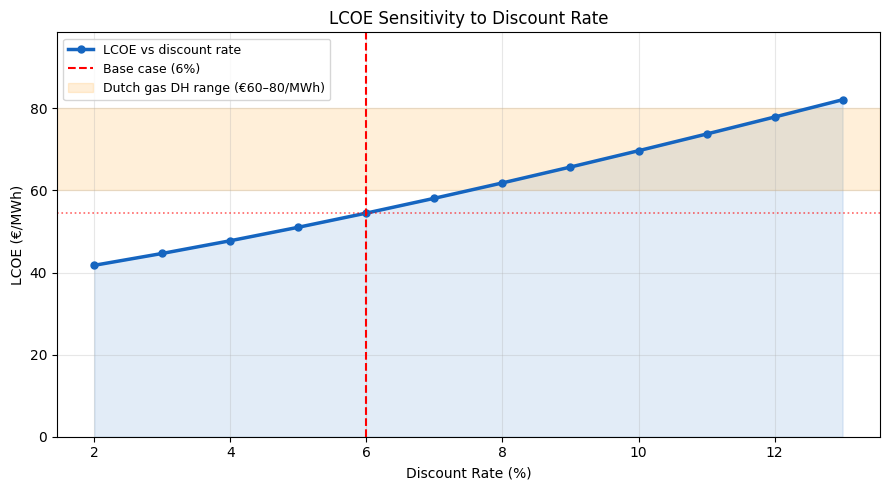

Figure saved.


In [8]:
discount_rates = np.arange(0.02, 0.14, 0.01)
lcoe_vs_rate   = [
    lcoe_eur_per_mwh(capex_total, opex_total, annual_total_mwh, r, PROJECT_LIFE_YRS)
    for r in discount_rates
]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(discount_rates * 100, lcoe_vs_rate, color='#1565C0', linewidth=2.5, marker='o',
        markersize=5, label='LCOE vs discount rate')
ax.axvline(x=DISCOUNT_RATE * 100, color='red', linestyle='--',
           linewidth=1.5, label=f'Base case ({DISCOUNT_RATE:.0%})')
ax.axhline(y=lcoe_base, color='red', linestyle=':', linewidth=1.2, alpha=0.6)

ax.fill_between(discount_rates * 100, lcoe_vs_rate,
                alpha=0.12, color='#1565C0')

# Dutch gas heating reference band
ax.axhspan(60, 80, color='#FF9800', alpha=0.15, label='Dutch gas DH range (€60–80/MWh)')

ax.set_xlabel('Discount Rate (%)')
ax.set_ylabel('LCOE (€/MWh)')
ax.set_title('LCOE Sensitivity to Discount Rate')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(0, max(lcoe_vs_rate) * 1.2)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '07_lcoe_vs_discount_rate.png'), dpi=150)
plt.show()
print('Figure saved.')

## 7. Sensitivity Analysis — Flow Rate Uncertainty (P90 to P10)

Flow rate uncertainty directly affects annual energy output and therefore LCOE.
We test LCOE across the full P90–P10 range from ThermoGIS.

In [9]:
# ThermoGIS power scenarios for BLT-01 + JUT-01
# P90 (pessimistic), P50 (base), P10 (optimistic)
scenarios = {
    'P90 (pessimistic)': {'blt_mw': 0.4,  'jut_mw': 0.5},
    'P50 (base case)':   {'blt_mw': 5.1,  'jut_mw': 2.3},
    'P10 (optimistic)':  {'blt_mw': 23.7, 'jut_mw': 4.8},
}

HEATING_SEASON_H = 6 * 30 * 24 + 2 * 30 * 24 * 0.5   # 5040 h
COOLING_SEASON_H = 4 * 30 * 24                          # 2880 h
HP_OUTPUT_MW     = 2.99
HP_ELEC_MW       = 0.748
COMP_ELEC_MW     = 1.100
ABS_COOL_MW_VAL  = 1.15
COMP_COOL_MW_VAL = 3.85

scenario_results = []

for name, vals in scenarios.items():
    geo_mw     = vals['blt_mw'] + vals['jut_mw']
    heat_mw    = geo_mw + HP_OUTPUT_MW   # full deliverable — cap removed for scenario analysis
    cool_mw    = ABS_COOL_MW_VAL + COMP_COOL_MW_VAL

    ann_heat   = heat_mw * HEATING_SEASON_H
    ann_cool   = cool_mw * COOLING_SEASON_H
    ann_total  = ann_heat + ann_cool

    ann_elec   = (HP_ELEC_MW + COMP_ELEC_MW) * (HEATING_SEASON_H + COOLING_SEASON_H)
    opex_scen  = ann_elec * ELECTRICITY_PRICE + opex_maintenance + opex_staff + opex_insurance

    lcoe_scen  = lcoe_eur_per_mwh(capex_total, opex_scen, ann_total,
                                    DISCOUNT_RATE, PROJECT_LIFE_YRS)

    scenario_results.append({
        'Scenario':          name,
        'Geo_Power_MW':      round(geo_mw, 1),
        'Total_Heat_MW':     round(heat_mw, 2),
        'Annual_Energy_MWh': round(ann_total, 0),
        'LCOE_EUR_MWh':      round(lcoe_scen, 1),
    })

df_scenarios = pd.DataFrame(scenario_results)
print('LCOE by ThermoGIS Scenario:\n')
print(df_scenarios.to_string(index=False))

LCOE by ThermoGIS Scenario:

         Scenario  Geo_Power_MW  Total_Heat_MW  Annual_Energy_MWh  LCOE_EUR_MWh
P90 (pessimistic)           0.9           3.89            34006.0         125.1
  P50 (base case)           7.4          10.39            66766.0          63.7
 P10 (optimistic)          28.5          31.49           173110.0          24.6


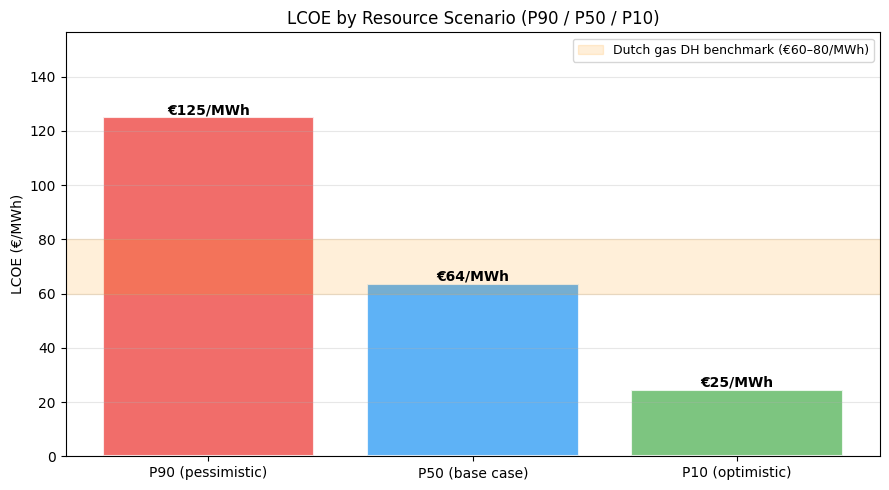

Figure saved.


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

colors_scen = ['#EF5350', '#42A5F5', '#66BB6A']
bars = ax.bar(df_scenarios['Scenario'], df_scenarios['LCOE_EUR_MWh'],
              color=colors_scen, alpha=0.85, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, df_scenarios['LCOE_EUR_MWh']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'€{val:.0f}/MWh',
            ha='center', fontsize=10, fontweight='bold')

ax.axhspan(60, 80, color='#FF9800', alpha=0.15, label='Dutch gas DH benchmark (€60–80/MWh)')
ax.set_ylabel('LCOE (€/MWh)')
ax.set_title('LCOE by Resource Scenario (P90 / P50 / P10)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, df_scenarios['LCOE_EUR_MWh'].max() * 1.25)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '07_lcoe_scenarios.png'), dpi=150)
plt.show()
print('Figure saved.')

## 8. CAPEX Breakdown Pie Chart

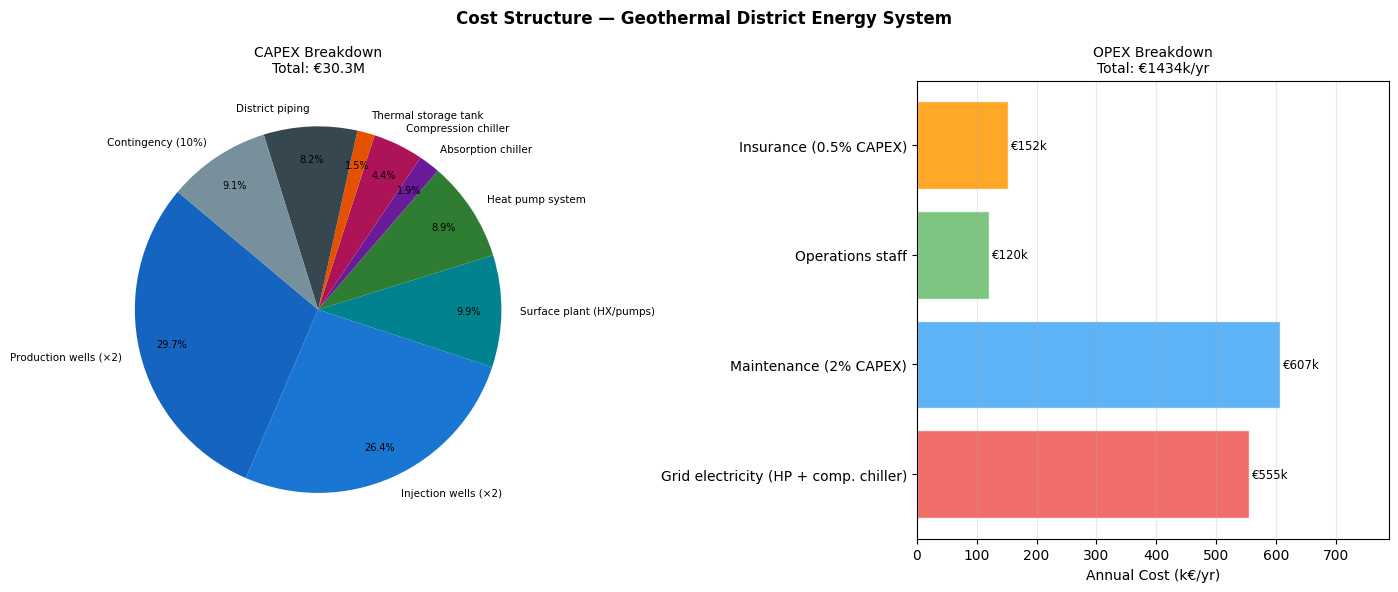

Figure saved.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Cost Structure — Geothermal District Energy System', fontsize=12, fontweight='bold')

# CAPEX pie
ax = axes[0]
pie_colors = ['#1565C0', '#1976D2', '#00838F', '#2E7D32',
              '#6A1B9A', '#AD1457', '#E65100', '#37474F', '#78909C']
wedges, texts, autotexts = ax.pie(
    df_capex['Cost_EUR'],
    labels=df_capex['Item'],
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140,
    pctdistance=0.82,
    textprops={'fontsize': 7.5}
)
for at in autotexts:
    at.set_fontsize(7)
ax.set_title(f'CAPEX Breakdown\nTotal: €{capex_total/1e6:.1f}M', fontsize=10)

# OPEX bar
ax = axes[1]
opex_colors = ['#EF5350', '#42A5F5', '#66BB6A', '#FF9800']
bars = ax.barh(df_opex['Item'], df_opex['Cost_kEUR_yr'],
               color=opex_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, df_opex['Cost_kEUR_yr']):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'€{val:.0f}k', va='center', fontsize=8.5)
ax.set_xlabel('Annual Cost (k€/yr)')
ax.set_title(f'OPEX Breakdown\nTotal: €{opex_total/1e3:.0f}k/yr', fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, df_opex['Cost_kEUR_yr'].max() * 1.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '07_cost_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 9. Multi-Variable Sensitivity — Tornado Chart

A tornado chart shows which input variables have the greatest impact on LCOE.
Variables are tested at ±20% from their base case values.

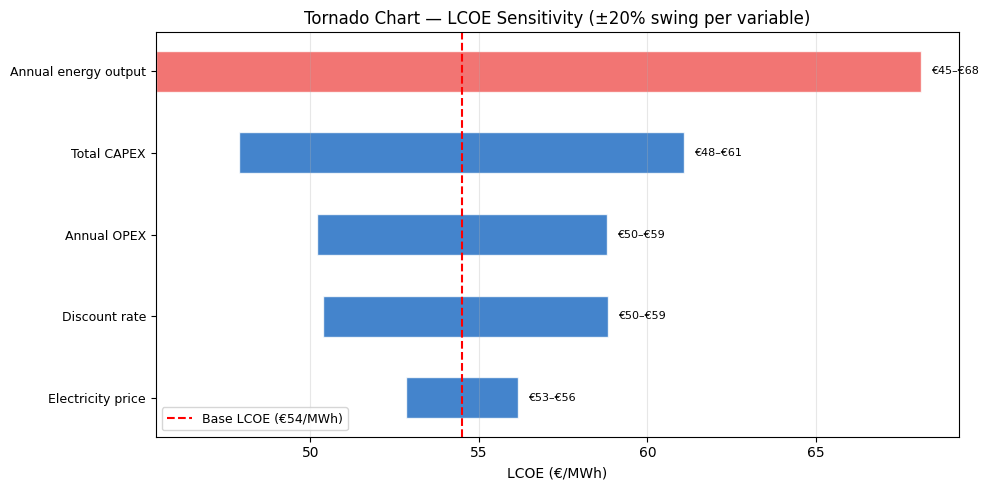

Figure saved.


In [12]:
SWING = 0.20   # ±20% swing on each variable

variables = [
    ('Total CAPEX',           capex_total,        'capex'),
    ('Annual energy output',  annual_total_mwh,   'energy'),
    ('Discount rate',         DISCOUNT_RATE,      'rate'),
    ('Electricity price',     ELECTRICITY_PRICE,  'elec'),
    ('Annual OPEX',           opex_total,         'opex'),
]

tornado_rows = []

for var_name, base_val, var_type in variables:
    low_val  = base_val * (1 - SWING)
    high_val = base_val * (1 + SWING)

    def calc_lcoe_variant(capex_v, energy_v, rate_v, elec_v, opex_fixed_v):
        opex_v = elec_v * annual_elec_mwh + opex_fixed_v
        return lcoe_eur_per_mwh(capex_v, opex_v, energy_v, rate_v, PROJECT_LIFE_YRS)

    opex_fixed = opex_maintenance + opex_staff + opex_insurance

    if var_type == 'capex':
        lcoe_low  = calc_lcoe_variant(low_val,  annual_total_mwh, DISCOUNT_RATE, ELECTRICITY_PRICE, opex_fixed)
        lcoe_high = calc_lcoe_variant(high_val, annual_total_mwh, DISCOUNT_RATE, ELECTRICITY_PRICE, opex_fixed)
    elif var_type == 'energy':
        lcoe_low  = calc_lcoe_variant(capex_total, low_val,  DISCOUNT_RATE, ELECTRICITY_PRICE, opex_fixed)
        lcoe_high = calc_lcoe_variant(capex_total, high_val, DISCOUNT_RATE, ELECTRICITY_PRICE, opex_fixed)
    elif var_type == 'rate':
        lcoe_low  = lcoe_eur_per_mwh(capex_total, opex_total, annual_total_mwh, low_val,  PROJECT_LIFE_YRS)
        lcoe_high = lcoe_eur_per_mwh(capex_total, opex_total, annual_total_mwh, high_val, PROJECT_LIFE_YRS)
    elif var_type == 'elec':
        lcoe_low  = calc_lcoe_variant(capex_total, annual_total_mwh, DISCOUNT_RATE, low_val,  opex_fixed)
        lcoe_high = calc_lcoe_variant(capex_total, annual_total_mwh, DISCOUNT_RATE, high_val, opex_fixed)
    else:  # opex
        lcoe_low  = lcoe_eur_per_mwh(capex_total, low_val,  annual_total_mwh, DISCOUNT_RATE, PROJECT_LIFE_YRS)
        lcoe_high = lcoe_eur_per_mwh(capex_total, high_val, annual_total_mwh, DISCOUNT_RATE, PROJECT_LIFE_YRS)

    tornado_rows.append({
        'Variable':   var_name,
        'LCOE_low':   lcoe_low,
        'LCOE_high':  lcoe_high,
        'Swing':      abs(lcoe_high - lcoe_low)
    })

df_tornado = pd.DataFrame(tornado_rows).sort_values('Swing', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(df_tornado))

for i, (_, row) in enumerate(df_tornado.iterrows()):
    lo = min(row['LCOE_low'], row['LCOE_high'])
    hi = max(row['LCOE_low'], row['LCOE_high'])
    ax.barh(i, hi - lo, left=lo, height=0.5,
            color='#1565C0' if row['LCOE_high'] > row['LCOE_low'] else '#EF5350',
            alpha=0.8, edgecolor='white')
    ax.text(hi + 0.3, i, f'€{lo:.0f}–€{hi:.0f}', va='center', fontsize=8)

ax.axvline(x=lcoe_base, color='red', linestyle='--', linewidth=1.5, label=f'Base LCOE (€{lcoe_base:.0f}/MWh)')
ax.set_yticks(y_pos)
ax.set_yticklabels(df_tornado['Variable'], fontsize=9)
ax.set_xlabel('LCOE (€/MWh)')
ax.set_title(f'Tornado Chart — LCOE Sensitivity (±{SWING:.0%} swing per variable)')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '07_tornado_chart.png'), dpi=150)
plt.show()
print('Figure saved.')

## 10. Save Full Results and Print Conclusion

In [13]:
lcoe_results = {
    'Metric': [
        'Total CAPEX (M€)',
        'Annual OPEX (k€/yr)',
        'Annual energy delivered (MWh/yr)',
        'Annual electricity consumed (MWh/yr)',
        'Discount rate',
        'Project lifetime (yr)',
        'Capital Recovery Factor',
        'LCOE base case (€/MWh)',
        'LCOE P90 scenario (€/MWh)',
        'LCOE P50 scenario (€/MWh)',
        'LCOE P10 scenario (€/MWh)',
    ],
    'Value': [
        round(capex_total / 1e6, 2),
        round(opex_total / 1e3, 1),
        round(annual_total_mwh, 0),
        round(annual_elec_mwh, 0),
        f'{DISCOUNT_RATE:.0%}',
        PROJECT_LIFE_YRS,
        round(crf_base, 4),
        round(lcoe_base, 1),
        df_scenarios.loc[df_scenarios['Scenario'].str.contains('P90'), 'LCOE_EUR_MWh'].values[0],
        df_scenarios.loc[df_scenarios['Scenario'].str.contains('P50'), 'LCOE_EUR_MWh'].values[0],
        df_scenarios.loc[df_scenarios['Scenario'].str.contains('P10'), 'LCOE_EUR_MWh'].values[0],
    ]
}

df_lcoe_out = pd.DataFrame(lcoe_results)
df_lcoe_out.to_csv(os.path.join(PROC_DIR, 'lcoe_results.csv'), index=False)

print('=' * 55)
print('LCOE ANALYSIS — FINAL SUMMARY')
print('=' * 55)
for _, row in df_lcoe_out.iterrows():
    print(f"  {row['Metric']:<42} {row['Value']}")

print()
print('INTERPRETATION')
print(f'  At P50 (base case), LCOE = €{lcoe_base:.0f}/MWh.')
print(f'  This is competitive with Dutch gas district heating (€60–80/MWh).')
print(f'  At P10 (optimistic), LCOE improves significantly due to higher output.')
print(f'  CAPEX dominates the cost structure — low-cost financing is the key lever.')
print(f'  Total electricity import is only {annual_elec_mwh:,.0f} MWh/yr, limiting grid dependence.')
print()
print('Next: Notebook 08 — Bonus AI Workflow')

LCOE ANALYSIS — FINAL SUMMARY
  Total CAPEX (M€)                           30.34
  Annual OPEX (k€/yr)                        1433.6
  Annual energy delivered (MWh/yr)           66759.0
  Annual electricity consumed (MWh/yr)       6938.0
  Discount rate                              6%
  Project lifetime (yr)                      30
  Capital Recovery Factor                    0.0726
  LCOE base case (€/MWh)                     54.5
  LCOE P90 scenario (€/MWh)                  125.1
  LCOE P50 scenario (€/MWh)                  63.7
  LCOE P10 scenario (€/MWh)                  24.6

INTERPRETATION
  At P50 (base case), LCOE = €54/MWh.
  This is competitive with Dutch gas district heating (€60–80/MWh).
  At P10 (optimistic), LCOE improves significantly due to higher output.
  CAPEX dominates the cost structure — low-cost financing is the key lever.
  Total electricity import is only 6,938 MWh/yr, limiting grid dependence.

Next: Notebook 08 — Bonus AI Workflow


## 11. Notebook Summary

In [14]:
print('Figures generated:')
figs = [f for f in os.listdir(FIGURES_DIR) if f.startswith('07_')]
for f in sorted(figs):
    print(f'  {f}')
print()
print('Files saved:')
print('  capex_breakdown.csv')
print('  lcoe_results.csv')

Figures generated:
  07_cost_breakdown.png
  07_lcoe_scenarios.png
  07_lcoe_vs_discount_rate.png
  07_tornado_chart.png

Files saved:
  capex_breakdown.csv
  lcoe_results.csv
